# EnergyScope Results Analysis - Norte Amazonica

Optimisation **EnergyScope MultiCell** de la region *Norte Amazonica* (Bolivie), represented by **5 cellules clusterisees** (C1-C5) qui preservent les differences de connectivite au reseau, de densite de population et d'infrastructure existante.

**Research question** : *how should this isolated region plan its energy transition under different demand and transition scenarios ?*

This notebook analyses **one scenario** in detail (`SCENARIO`, defined below), puis compare en section 12 la **sufficiency phase 2** (reference) aux scenarios **reality phase 1** et **reality phase 2**, afin de comparer les strategies d'approvisionnement.

## Plan
1. Executive summary - corrected indicators
2. **End-use demand** - what drives the system
3. **Mix d'approvisionnement electrique** - d'ou vient reellement l'electricite
4. **Autonomy & imports** - external dependence by region
5. Costs - breakdown + intensity (EUR/MWh)
6. Carbon footprint (GWP) + intensity
7. Stockage
8. Curtailment & flexibility
9. Inter-regional exchanges
10. Hourly profiles - electric dispatch vs demand
11. Synthese
12. **Comparaison de scenarios** - sufficiency P2 vs reality P1 vs reality P2

---
**Units**: costs in M€/year . energy in GWh/year . capacity in GW . GWP in kt CO2-eq/year

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

In [20]:
# ============================================================================
#  CONFIGURATION  -  change SCENARIO to analyse / compare another run
# ============================================================================
ROOT = Path('case_studies/C1_C2_C3_C4_C5')
DATA = Path('Data/2025')     # inputs are now split per demand scenario: sufficiency/ and reality/

# -- Main scenario, analysed in detail in sections 1-11 ----------------------
SCENARIO = 'norte_amazonia_sufficiency_2025_phase2'
DATA_DIR = DATA / 'sufficiency'          # input folder matching SCENARIO

BASE   = ROOT / SCENARIO / 'outputs'
REG    = BASE / 'regional_results'
HOURLY = BASE / 'hourly_results'

# -- Comparison set, section 12 ---------------------------------------------
SCEN_REF = 'Sufficiency P2'              # reference against which deltas are computed
COMPARE = {
    'Sufficiency P2': 'norte_amazonia_sufficiency_2025_phase2',
    'Reality P1':     'norte_amazonia_reality_2025',
    'Reality P2':     'norte_amazonia_reality_2025_phase2',
}
PHASE2_SCEN = {'Sufficiency P2', 'Reality P2'}   # carry the BC grid-extension CAPEX
SCEN_COLORS = {'Sufficiency P2': '#E4848F', 'Reality P1': '#8FC7A8', 'Reality P2': '#5A9AE3'}

REGIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
# Human-readable labels (fill in with the actual cluster geography)
REGION_LABELS = {r: r for r in REGIONS}

EPS = 1e-6   # seuil "non nul"

# -- Storage technologies (to exclude from production mixes) -----------------
STORAGE_TECHS = {'BATT_LI', 'BATT_HS', 'CAES', 'PHS', 'DAM_STORAGE', 'TS_DEC_HP_ELEC',
                 'TS_HIGH_TEMP', 'GAS_STORAGE', 'H2_STORAGE', 'DIESEL_STORAGE',
                 'LPG_STORAGE', 'GASOLINE_STORAGE', 'JET_FUEL_STORAGE', 'LNG_STORAGE',
                 'AMMONIA_STORAGE', 'METHANOL_STORAGE', 'CO2_STORAGE'}

# -- Renewable / fossil / import classification for the electricity vector ----
RENEW_ELEC  = {'PV_UTILITY', 'PV_ROOFTOP', 'PV_HS', 'WIND_ONSHORE', 'WIND_OFFSHORE',
               'HYDRO_DAM', 'HYDRO_RIVER', 'TIDAL_STREAM', 'TIDAL_RANGE', 'WAVE',
               'GEOTHERMAL', 'BIOMASS_TO_POWER', 'ST_BIOMASS', 'ST_SNG'}
FOSSIL_ELEC = {'GENSET_DIESEL', 'HS_DIESEL', 'OCGT', 'CCGT', 'CCGT_AMMONIA',
               'COAL_US', 'COAL_IGCC', 'NUCLEAR', 'NUCLEAR_SMR'}
IMPORT_ELEC = {'ELECTRICITY'}   # la ressource ELECTRICITY = import depuis l'exterieur

# -- Short technology names --------------------------------------------------
TECH_LABELS = {
    'PV_UTILITY': 'PV utility', 'PV_ROOFTOP': 'PV rooftop', 'PV_HS': 'PV household',
    'WIND_ONSHORE': 'Onshore wind', 'HYDRO_DAM': 'Hydro dam', 'HYDRO_RIVER': 'Run-of-river hydro',
    'GEOTHERMAL': 'Geothermal', 'BIOMASS_TO_POWER': 'Biomass power',
    'ST_SNG': 'SNG turbine', 'ST_BIOMASS': 'Biomass turbine',
    'GENSET_DIESEL': 'Diesel genset', 'HS_DIESEL': 'Household diesel',
    'OCGT': 'OCGT', 'CCGT': 'CCGT', 'ELECTRICITY': 'Electricity import',
    'BATT_LI': 'Li-ion battery', 'BATT_HS': 'Household battery',
}
def get_label(t): return TECH_LABELS.get(t, t)

# -- Technology colours (electricity mix) ------------------------------------
TECH_COLORS = {
    'PV_UTILITY':        "#E9B081",
    'PV_ROOFTOP':        "#CE8A68",
    'PV_HS':             "#FCDBB7",
    'WIND_ONSHORE':      '#52A8D8',
    'HYDRO_DAM':         '#1B5E8C',
    'HYDRO_RIVER':       "#3D83B1",
    'GEOTHERMAL':        '#A0789E',
    'BIOMASS_TO_POWER':  '#6BA888',
    'ST_BIOMASS':        '#539C78',
    'ST_SNG':            '#8EC4A8',
    'GENSET_DIESEL':     '#7B8FA0',
    'HS_DIESEL':         '#A8B8C4',
    'OCGT':              '#8BB4C8',
    'CCGT':              '#5F8FA8',
    'ELECTRICITY':       "#56A0F5",
    'BATT_LI':           '#9370DB',
    'BATT_HS':           '#6A0DAD',
}
def get_color(t): return TECH_COLORS.get(t, '#B0C4D4')

# -- End-uses (demand): labels + colours -------------------------------------
EUD_LABELS = {
    'COOKING': 'Cooking', 'ELECTRICITY': 'Direct electricity',
    'SPACE_COOLING': 'Space cooling', 'FOOD_PRESERVATION': 'Refrigeration',
    'HEAT_LOW_T_DECEN': 'Low-T heat', 'LIGHTING_R_C': 'Res./com. lighting',
    'LIGHTING_P': 'Public lighting', 'MECHANICAL_ENERGY_COMM': 'Mech. commerce',
    'MECHANICAL_ENERGY_IND': 'Mech. industry',
    'MECHANICAL_ENERGY_FIX_AGR': 'Mech. agriculture',
    'MECHANICAL_ENERGY_FISH_OTHERS': 'Mech. fishing',
}
EUD_COLORS = {
    'COOKING':                      "#DA7C7C",
    'ELECTRICITY':                  "#3A81C0",
    'SPACE_COOLING':                '#74C4D8',
    'FOOD_PRESERVATION':            "#6688BE",
    'HEAT_LOW_T_DECEN':             '#D48C60',
    'LIGHTING_R_C':                 '#C8A84A',
    'LIGHTING_P':                   '#A89050',
    'MECHANICAL_ENERGY_COMM':       '#7B6DC0',
    'MECHANICAL_ENERGY_IND':        '#524A98',
    'MECHANICAL_ENERGY_FIX_AGR':    '#6A9E7A',
    'MECHANICAL_ENERGY_FISH_OTHERS':'#4A9E98',
}
def eud_label(l): return EUD_LABELS.get(l, l)
def eud_color(l): return EUD_COLORS.get(l, '#B0C4D4')

print(f'Configuration loaded  OK')
print(f'  main scenario : {SCENARIO}')
print(f'  data folder   : {DATA_DIR}')
print(f'  comparison    : {list(COMPARE)}   (ref = {SCEN_REF})')

Configuration loaded  OK
  main scenario : norte_amazonia_sufficiency_2025_phase2
  data folder   : Data\2025\sufficiency
  comparison    : ['Sufficiency P2', 'Reality P1', 'Reality P2']   (ref = Sufficiency P2)


In [21]:
# -- Chargement centralise d'un scenario -------------------------------------
def num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def load_scenario(base):
    reg = base / 'regional_results'
    D = {}
    D['total_cost'] = pd.read_csv(reg / 'TotalCost.csv', sep=';')
    D['assets']     = num(pd.read_csv(reg / 'Assets.csv', sep=';'), ['F', 'F_year'])
    D['cost']       = num(pd.read_csv(reg / 'Cost_breakdown.csv', sep=';'), ['C_inv', 'C_maint', 'C_op'])
    D['gwp']        = num(pd.read_csv(reg / 'Gwp_breakdown.csv', sep=';'), ['GWP_constr', 'GWP_op', 'CO2_net'])
    D['curt']       = num(pd.read_csv(reg / 'Curt.csv', sep=';'), ['Curt'])
    D['sto']        = num(pd.read_csv(reg / 'Sto_assets.csv', sep=';'), ['F', 'Year_energy_flux', 'Losses'])
    D['exch']       = num(pd.read_csv(reg / 'Exchanges_year.csv', sep=';'), ['Exchanges_year', 'Transfer_capacity', 'Utilization_factor'])
    D['res']        = num(pd.read_csv(reg / 'Resources.csv', sep=';'),
                          ['R_year_local', 'R_year_exterior', 'R_year_import', 'R_year_export'])
    D['yb']         = pd.read_csv(reg / 'Year_balance.csv', sep=';')
    D['objective']  = pd.read_csv(base / 'Objective.csv', sep=';')
    D['solve']      = pd.read_csv(base / 'Solve_info.csv', sep=';')
    return D

D = load_scenario(BASE)
total_cost = D['total_cost']; total_cost = total_cost[total_cost['Regions'].isin(REGIONS)].copy()
assets, cost_reg, gwp_reg = D['assets'], D['cost'], D['gwp']
curt_reg, sto_reg, exch_reg, res_reg = D['curt'], D['sto'], D['exch'], D['res']
yb, objective, solve_info = D['yb'], D['objective'], D['solve']

# -- Year_balance helpers ----------------------------------------------------
def layer(yb, lay):
    '''Return (Regions, Elements, val) for a given energy layer.'''
    d = yb[['Regions', 'Elements', lay]].copy()
    d[lay] = pd.to_numeric(d[lay], errors='coerce').fillna(0)
    return d.rename(columns={lay: 'val'})

def elec_supply(yb, regions):
    '''Mix d'approvisionnement electrique : productions positives, hors stockage.'''
    d = layer(yb, 'ELECTRICITY')
    d = d[(d['val'] > EPS) & (~d['Elements'].isin(STORAGE_TECHS)) & (d['Regions'].isin(regions))]
    return d

def eud_demand(yb, regions):
    '''Useful demand by end-use and region (positive values, GWh/year).'''
    eu = yb[yb['Elements'] == 'END_USES'].set_index('Regions')
    out = {}
    for lay in EUD_LABELS:
        if lay in eu.columns:
            out[lay] = pd.to_numeric(eu[lay], errors='coerce').abs()
    dem = pd.DataFrame(out).reindex(regions).fillna(0)
    return dem.loc[:, dem.sum() > 1e-4]

print('Data loaded  OK')
print(f"  regions       : {sorted(yb['Regions'].unique())}")
print(f"  balance rows  : {len(yb)}   |   techs/resources : {yb['Elements'].nunique()}")

Data loaded  OK
  regions       : ['C1', 'C2', 'C3', 'C4', 'C5']
  balance rows  : 1520   |   techs/resources : 304


---
## 1. Executive summary

Indicateurs cles **corriges**. Attention : contrairement a une somme naive des `F_year` (qui agrege stockage, reseau et conversions et n'a pas de sens physique), la production electrique et la demande utile sont ici calculees a partir du **bilan annuel par vecteur** (`Year_balance`).

In [22]:
obj_value      = float(objective.iloc[0, -1])
solve_time_s   = float(solve_info[solve_info.iloc[:, 0].astype(str).str.contains('solve_elapsed', na=False)].iloc[0, 1])
total_sys_cost = total_cost['TotalCost'].sum()

# Production electrique reelle (vecteur ELECTRICITY, hors stockage)
es = elec_supply(yb, REGIONS)
elec_total   = es['val'].sum()
elec_import  = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()
elec_local   = elec_total - elec_import
elec_renew   = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()

# Demande utile totale (tous usages finaux)
dem = eud_demand(yb, REGIONS)
demande_totale = dem.values.sum()

# Emissions : GWP operationnel (coherent avec section 6 et synthese)
gwp_op_tot = pd.to_numeric(gwp_reg['GWP_op'], errors='coerce').fillna(0).sum()

# Technologies reellement deployees (capacite F > 0)
af = assets[assets['F'] > EPS]
n_active = af['Technologies'].nunique()

line = '=' * 60
print(line)
print(f'   EXECUTIVE SUMMARY - {SCENARIO}')
print(line)
print(f'  Total system cost             : {total_sys_cost:>9.2f} M€/year')
print(f'  Useful demand served          : {demande_totale:>9.1f} GWh/year')
print(f'  Electricity production        : {elec_total:>9.1f} GWh/year')
print(f'     . local                     : {elec_local:>9.1f} GWh/year ({elec_local/elec_total*100:4.1f} %)')
print(f'     . imported                  : {elec_import:>9.1f} GWh/year ({elec_import/elec_total*100:4.1f} %)')
print(f'     . renewable (local)         : {elec_renew:>9.1f} GWh/year ({elec_renew/elec_total*100:4.1f} %)')
print(f'  Operational GWP emissions     : {gwp_op_tot:>9.2f} kt CO2-eq/year')
print(f'  Average electricity cost      : {total_sys_cost*1000/demande_totale:>9.1f} EUR/MWh utile')
print(f'  Deployed technologies         : {n_active:>9d}')
print(f'  Solver elapsed time           : {solve_time_s:>9.1f} s')
print('-' * 60)
print('  Cost breakdown by region      :')
for _, r in total_cost.sort_values('TotalCost', ascending=False).iterrows():
    pct = r['TotalCost'] / total_sys_cost * 100
    bar = '#' * int(pct / 2)
    print(f'    {r["Regions"]}  {r["TotalCost"]:>6.2f} M-euro  {bar} {pct:4.1f}%')
print(line)

   EXECUTIVE SUMMARY - norte_amazonia_sufficiency_2025_phase2
  Total system cost             :     43.24 M€/year
  Useful demand served          :     285.3 GWh/year
  Electricity production        :     261.7 GWh/year
     . local                     :     244.8 GWh/year (93.5 %)
     . imported                  :      17.0 GWh/year ( 6.5 %)
     . renewable (local)         :     240.3 GWh/year (91.8 %)
  Operational GWP emissions     :     48.10 kt CO2-eq/year
  Average electricity cost      :     151.6 EUR/MWh utile
  Deployed technologies         :        35
  Solver elapsed time           :      46.5 s
------------------------------------------------------------
  Cost breakdown by region      :
    C3   22.11 M-euro  ######################### 51.1%
    C5   10.38 M-euro  ############ 24.0%
    C4    7.20 M-euro  ######## 16.6%
    C1    3.07 M-euro  ###  7.1%
    C2    0.47 M-euro    1.1%


---
## 2. End-use demand

C'est le **point de depart** de la these : la strategie d'approvisionnement optimale depend directement de la structure de la demande. On lit ici la demande *utile* (sortie de la ligne `END_USES` du bilan), independamment du vecteur qui la satisfait.

> La comparaison `sufficiency` vs `reality` se lit directement sur ce graphique : meme code, `SCENARIO` different. La section 12 la produit pour les trois scenarios.

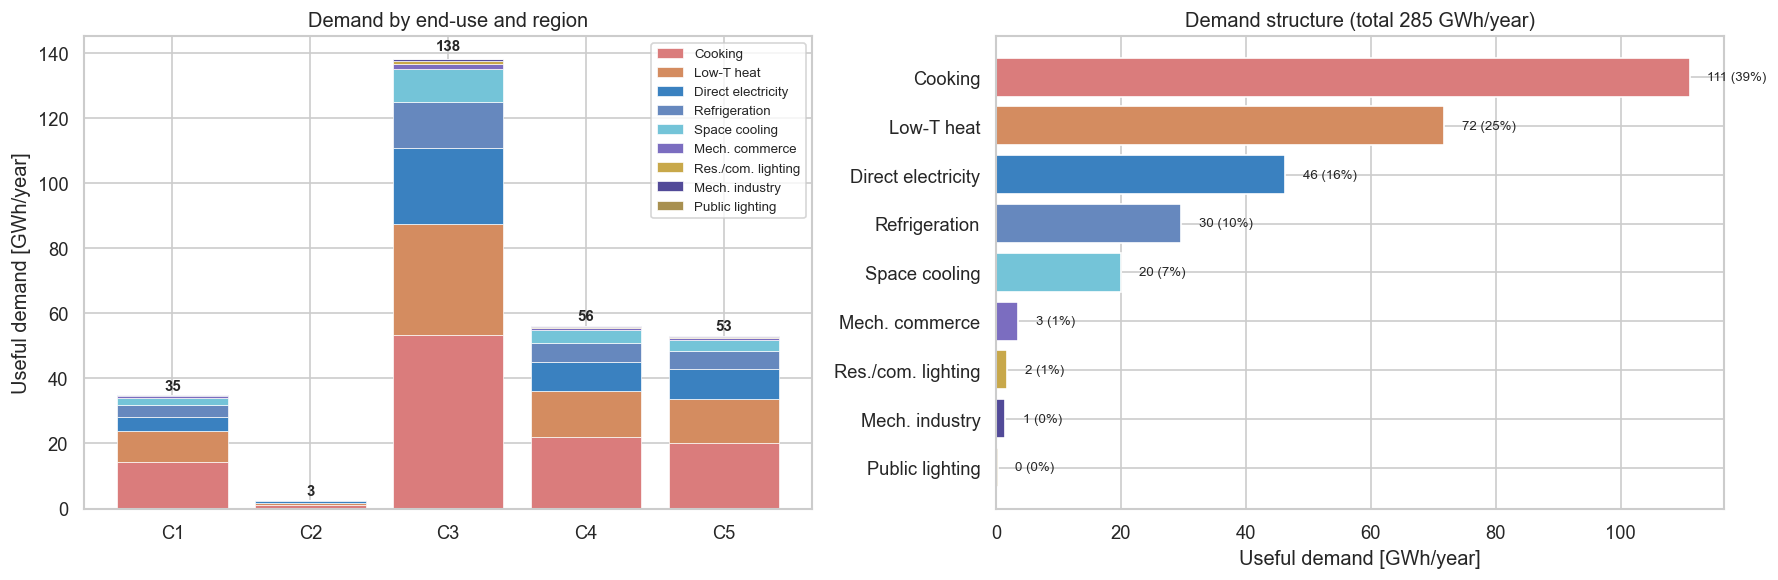

Useful demand by end-use and region [GWh/year]:
         COOKING  ELECTRICITY  SPACE_COOLING  FOOD_PRESERVATION  HEAT_LOW_T_DECEN  LIGHTING_R_C  LIGHTING_P  MECHANICAL_ENERGY_COMM  MECHANICAL_ENERGY_IND
Regions                                                                                                                                                   
C1         14.41         4.29           2.23               3.84              9.30          0.22        0.03                    0.44                   0.18
C2          1.07         0.45           0.19               0.28              0.68          0.02        0.00                    0.03                   0.01
C3         53.22        23.30          10.05              14.16             34.30          0.82        0.10                    1.65                   0.67
C4         22.02         8.91           3.99               5.83             14.14          0.33        0.04                    0.67                   0.26
C5         20.28      

In [23]:
dem = eud_demand(yb, REGIONS)
dem_sorted = dem[dem.sum().sort_values(ascending=False).index]   # usages dominants d'abord

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- (a) demand by end-use and region ---------------------------------------
ax = axes[0]
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
for lay in dem_sorted.columns:
    ax.bar(x, dem_sorted[lay].values, bottom=bottom, label=eud_label(lay),
           color=eud_color(lay), edgecolor='white', linewidth=.4)
    bottom += dem_sorted[lay].values
for xi, tot in zip(x, dem.sum(axis=1).values):
    ax.text(xi, tot + tot*0.01 + 0.3, f'{tot:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[r] for r in REGIONS])
ax.set_ylabel('Useful demand [GWh/year]')
ax.set_title('Demand by end-use and region')
ax.legend(fontsize=8, loc='upper right')

# -- (b) relative structure (share per use, all regions) --------------------
ax = axes[1]
shares = dem.sum().sort_values(ascending=True)
ax.barh(range(len(shares)), shares.values, color=[eud_color(l) for l in shares.index], edgecolor='white')
ax.set_yticks(range(len(shares))); ax.set_yticklabels([eud_label(l) for l in shares.index])
tot = shares.sum()
for i, v in enumerate(shares.values):
    ax.text(v + tot*0.01, i, f'{v:.0f} ({v/tot*100:.0f}%)', va='center', fontsize=8)
ax.set_xlabel('Useful demand [GWh/year]')
ax.set_title(f'Demand structure (total {tot:.0f} GWh/year)')
plt.tight_layout(); plt.show()

print('Useful demand by end-use and region [GWh/year]:')
print(dem.round(2).to_string())

---
## 3. Mix d'approvisionnement electrique

D'ou vient **reellement** l'electricite, par region et au total. Lecture directe du vecteur `ELECTRICITY` du bilan (productions positives, stockage exclu). L'**import** (ressource `ELECTRICITY`) est distingue de la production locale.

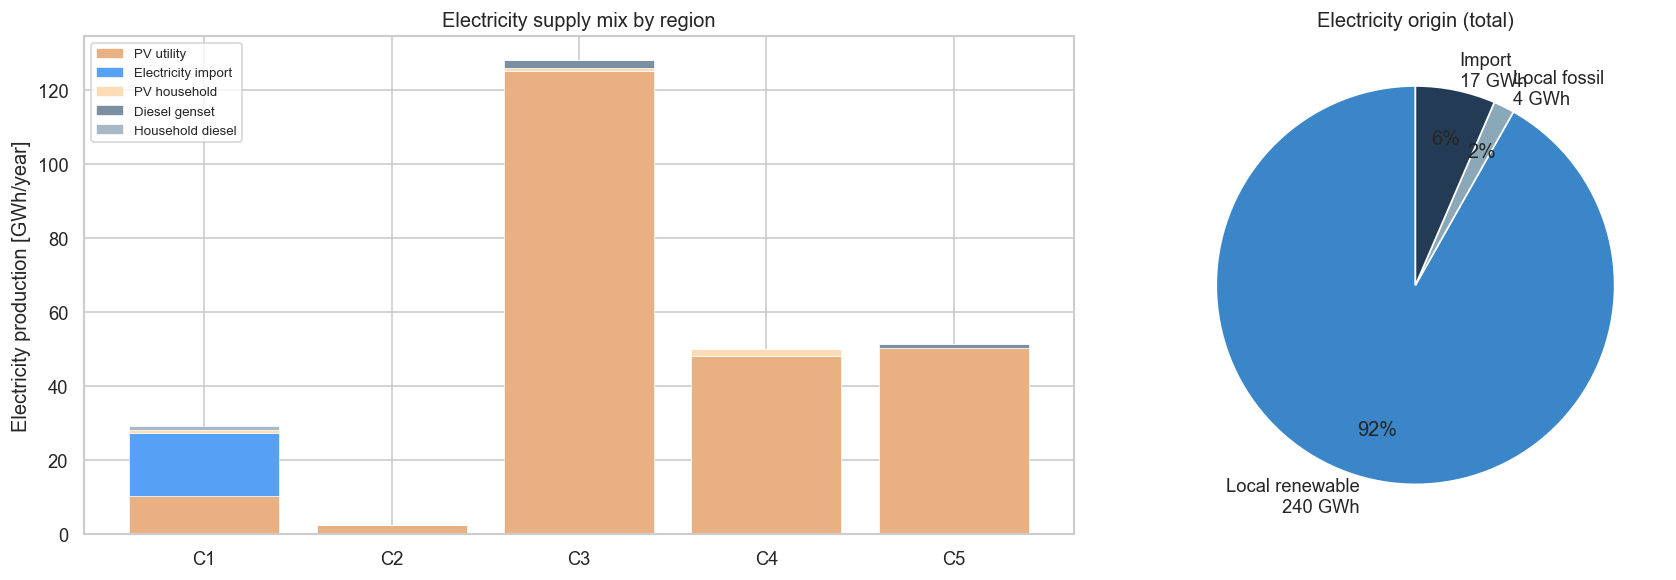

Electricity mix by region [GWh/year]:
Elements  PV_UTILITY  ELECTRICITY  PV_HS  GENSET_DIESEL  HS_DIESEL
Regions                                                           
C1             10.31        16.97   1.00           0.00       1.04
C2              2.47         0.00   0.08           0.00       0.02
C3            125.28         0.00   0.69           2.26       0.03
C4             48.22         0.00   1.86           0.00       0.03
C5             50.39         0.00   0.00           1.10       0.00


In [24]:
es = elec_supply(yb, REGIONS)
pivot = es.pivot_table(index='Regions', columns='Elements', values='val', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
pivot = pivot[pivot.sum().sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.4, 1]})

# -- (a) mix by region ------------------------------------------------------
ax = axes[0]
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
for tech in pivot.columns:
    ax.bar(x, pivot[tech].values, bottom=bottom, label=get_label(tech),
           color=get_color(tech), edgecolor='white', linewidth=.4)
    bottom += pivot[tech].values
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[r] for r in REGIONS])
ax.set_ylabel('Electricity production [GWh/year]')
ax.set_title('Electricity supply mix by region')
ax.legend(fontsize=8, loc='upper left')

# -- (b) renewable / fossil / import split (aggregated) ---------------------
ax = axes[1]
cat = {'Local renewable': es[es['Elements'].isin(RENEW_ELEC)]['val'].sum(),
       'Local fossil':      es[es['Elements'].isin(FOSSIL_ELEC)]['val'].sum(),
       'Import':             es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()}
cat = {k: v for k, v in cat.items() if v > EPS}
cols = {'Local renewable': '#3A86C8', 'Local fossil': '#8BA8B8', 'Import': '#243B55'}
ax.pie(cat.values(), labels=[f'{k}\n{v:.0f} GWh' for k, v in cat.items()],
       colors=[cols[k] for k in cat], autopct='%1.0f%%', startangle=90, pctdistance=0.75)
ax.set_title('Electricity origin (total)')
plt.tight_layout(); plt.show()

print('Electricity mix by region [GWh/year]:')
print(pivot.round(2).to_string())

---
## 4. Autonomy & import dependence

Question centrale pour une region **isolee** : quelle part de l'energie est produite localement vs importee de l'exterieur (electricite du Bresil/SIN, diesel, GPL...) ? On combine l'import d'electricite et les ressources fossiles importees (`Resources.csv`).

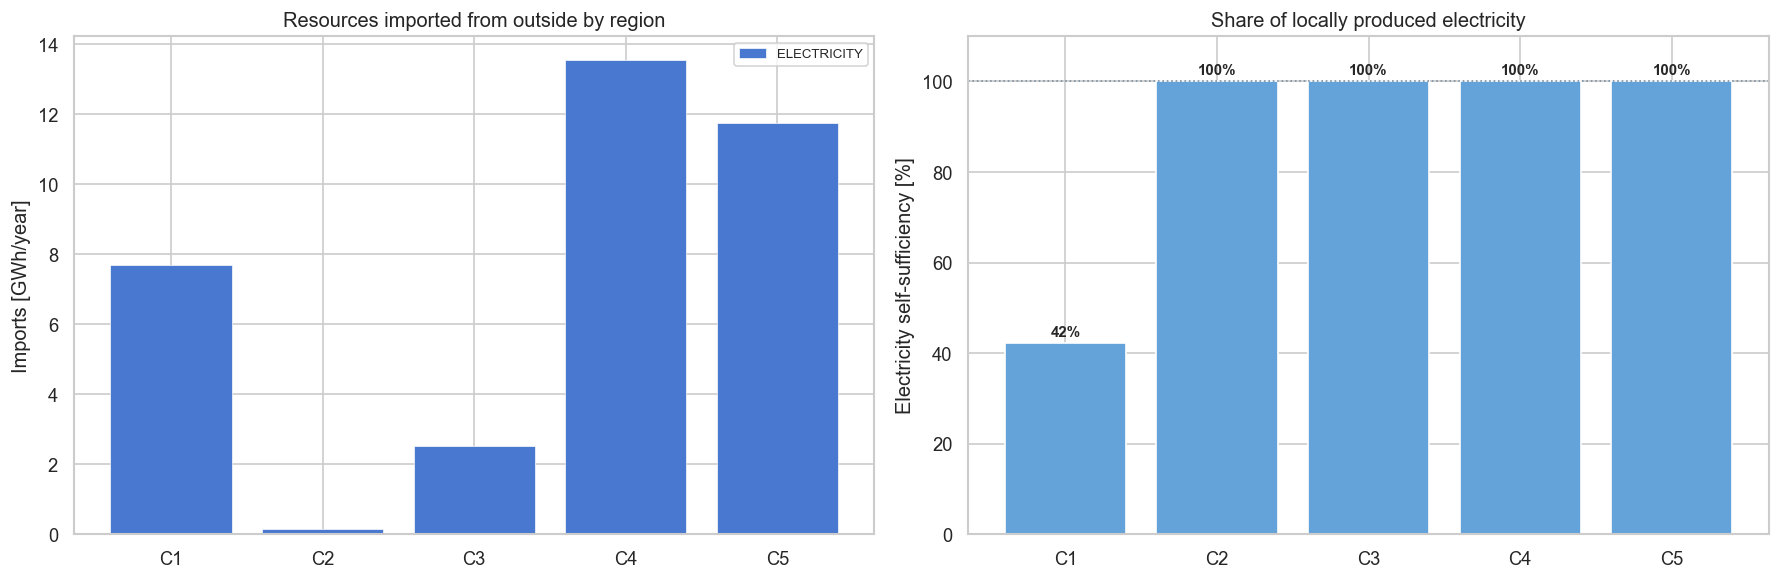

Imports by resource and region [GWh/year]:
Resources  ELECTRICITY
Regions               
C1                7.68
C2                0.16
C3                2.52
C4               13.55
C5               11.75


In [25]:
r = res_reg[res_reg['Regions'].isin(REGIONS)].copy()
imp = r[r['R_year_import'] > EPS].pivot_table(index='Regions', columns='Resources',
        values='R_year_import', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- (a) resource imports by region -----------------------------------------
ax = axes[0]
imp_s = imp[imp.sum().sort_values(ascending=False).index] if not imp.empty else imp
bottom = np.zeros(len(REGIONS)); x = np.arange(len(REGIONS))
palette = sns.color_palette('muted', max(len(imp_s.columns), 1))
for c, col in zip(imp_s.columns, palette):
    ax.bar(x, imp_s[c].values, bottom=bottom, label=c, color=col, edgecolor='white', linewidth=.4)
    bottom += imp_s[c].values
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Imports [GWh/year]')
ax.set_title('Resources imported from outside by region')
ax.legend(fontsize=8)

# -- (b) electricity self-sufficiency rate by region ------------------------
ax = axes[1]
es = elec_supply(yb, REGIONS)
loc = es[~es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
imp_el = es[es['Elements'].isin(IMPORT_ELEC)].groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
tot_el = (loc + imp_el).replace(0, np.nan)
auto = (loc / tot_el * 100).fillna(0)
bars = ax.bar(x, auto.values, color="#63A3DA", edgecolor='white')
for b, v in zip(bars, auto.values):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(100, color='#7B8FA0', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels([REGION_LABELS[rr] for rr in REGIONS])
ax.set_ylabel('Electricity self-sufficiency [%]'); ax.set_ylim(0, 110)
ax.set_title('Share of locally produced electricity')
plt.tight_layout(); plt.show()

print('Imports by resource and region [GWh/year]:')
print((imp.round(2).to_string() if not imp.empty else '  no imports'))

---
## 5. Costs

Decomposition investissement / maintenance / operation, et surtout **intensite de cout** (EUR/MWh de demande utile servie) par region - l'indicateur qui relie directement la strategie d'approvisionnement a la question de recherche.

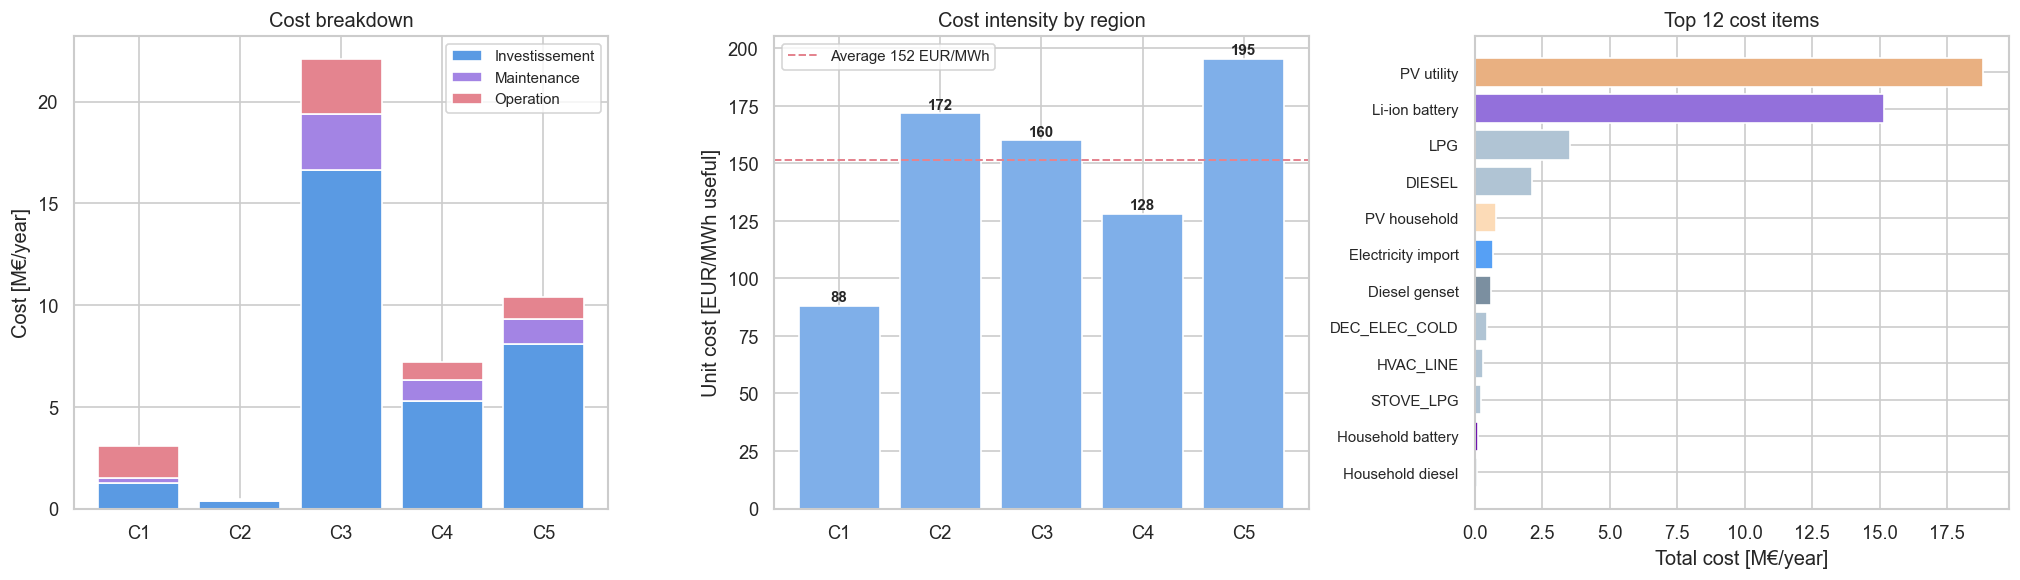

Costs by region [M€/year]:
         C_inv  C_maint  C_op  Total
Regions                             
C1        1.23     0.25  1.60   3.07
C2        0.37     0.05  0.05   0.47
C3       16.63     2.75  2.73  22.11
C4        5.28     1.03  0.88   7.20
C5        8.09     1.20  1.09  10.38


In [26]:
c = cost_reg[cost_reg['Regions'].isin(REGIONS)].copy()
for col in ['C_inv', 'C_maint', 'C_op']:
    c[col] = c[col].fillna(0)
by_reg = c.groupby('Regions')[['C_inv', 'C_maint', 'C_op']].sum().reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# -- (a) breakdown by region ------------------------------------------------
ax = axes[0]
x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
parts = [('C_inv', "#5A9AE3", 'Investissement'), ('C_maint', "#A384E4", 'Maintenance'), ('C_op', "#E4848F", 'Operation')]
for col, color, lab in parts:
    ax.bar(x, by_reg[col].values, bottom=bottom, color=color, label=lab, edgecolor='white')
    bottom += by_reg[col].values
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Cost [M€/year]'); ax.set_title('Cost breakdown'); ax.legend(fontsize=9)

# -- (b) cost intensity EUR/MWh useful --------------------------------------
ax = axes[1]
dem = eud_demand(yb, REGIONS)
dem_reg = dem.sum(axis=1).reindex(REGIONS)
intens = (by_reg.sum(axis=1) * 1000 / dem_reg).reindex(REGIONS)
moy = total_cost['TotalCost'].sum()*1000/dem.values.sum()
bars = ax.bar(x, intens.values, color="#7FAFE9", edgecolor='white')
ax.axhline(moy, color="#E4848F", ls='--', lw=1.2, label=f'Average {moy:.0f} EUR/MWh')
for b, v in zip(bars, intens.values):
    ax.text(b.get_x()+b.get_width()/2, v+intens.max()*0.01, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('Unit cost [EUR/MWh useful]')
ax.set_title('Cost intensity by region'); ax.legend(fontsize=9)

# -- (c) top technologies by cost -------------------------------------------
ax = axes[2]
c['tot'] = c['C_inv'] + c['C_maint'] + c['C_op']
top = c.groupby('Elements')['tot'].sum().sort_values(ascending=False).head(12)
ax.barh(range(len(top)), top.values[::-1], color=[get_color(t) for t in top.index[::-1]], edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels([get_label(t) for t in top.index[::-1]], fontsize=9)
ax.set_xlabel('Total cost [M€/year]'); ax.set_title('Top 12 cost items')
plt.tight_layout(); plt.show()

print('Costs by region [M€/year]:')
print(by_reg.assign(Total=by_reg.sum(axis=1)).round(2).to_string())

---
## 6. Carbon footprint (GWP)

- **GWP_constr**: equipment manufacturing emissions
- **GWP_op**: operational emissions (combustion, processes)
- **CO2_net**: net balance

Intensite reportee en **g CO2/kWh** d'electricite produite.

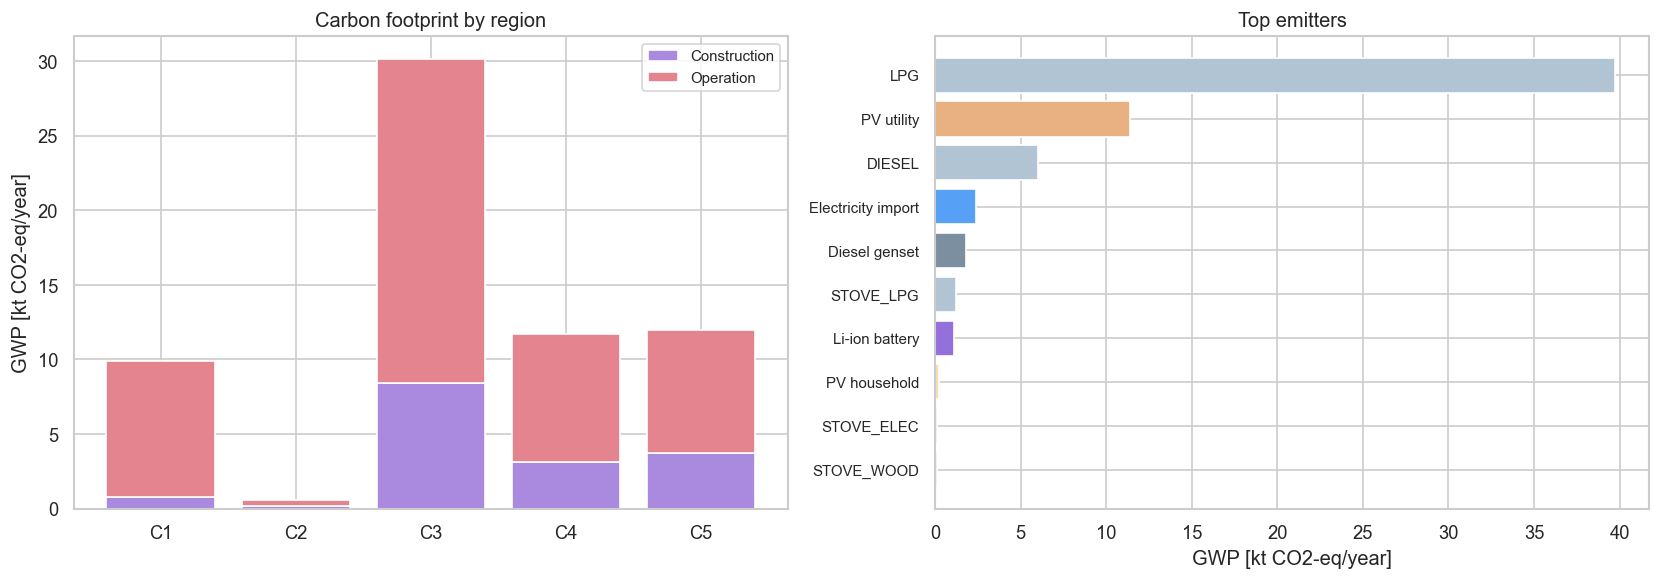

GWP operationnel total : 48.10 kt CO2-eq/year
Intensite electrique   : 183.8 g CO2/kWh produit


In [27]:
g = gwp_reg[gwp_reg['Regions'].isin(REGIONS)].copy()
for col in ['GWP_constr', 'GWP_op', 'CO2_net']:
    g[col] = g[col].fillna(0)
by_reg = g.groupby('Regions')[['GWP_constr', 'GWP_op']].sum().reindex(REGIONS).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- (a) GWP construction vs operation by region ----------------------------
ax = axes[0]
x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
for col, color, lab in [('GWP_constr', "#A98ADE", 'Construction'), ('GWP_op', "#E4848F", 'Operation')]:
    ax.bar(x, by_reg[col].values, bottom=bottom, color=color, label=lab, edgecolor='white')
    bottom += by_reg[col].values
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('GWP [kt CO2-eq/year]'); ax.set_title('Carbon footprint by region'); ax.legend(fontsize=9)

# -- (b) top emitters -------------------------------------------------------
ax = axes[1]
g['tot'] = g['GWP_constr'] + g['GWP_op']
top = g.groupby('Elements')['tot'].sum().sort_values(ascending=False).head(10)
top = top[top > EPS]
if len(top):
    ax.barh(range(len(top)), top.values[::-1], color=[get_color(t) for t in top.index[::-1]], edgecolor='white')
    ax.set_yticks(range(len(top))); ax.set_yticklabels([get_label(t) for t in top.index[::-1]], fontsize=9)
    ax.set_xlabel('GWP [kt CO2-eq/year]'); ax.set_title('Top emitters')
else:
    ax.text(0.5, 0.5, 'Negligible emissions', ha='center', va='center')
plt.tight_layout(); plt.show()

elec_total = elec_supply(yb, REGIONS)['val'].sum()
co2_op = g['GWP_op'].sum()
print(f'GWP operationnel total : {co2_op:.2f} kt CO2-eq/year')
print(f'Intensite electrique   : {co2_op/elec_total*1000:.1f} g CO2/kWh produit')

---
## 7. Storage

Deployed storage assets (capacity `F`, annual cycled energy) and average **state-of-charge profile** over the day (Li-ion battery).

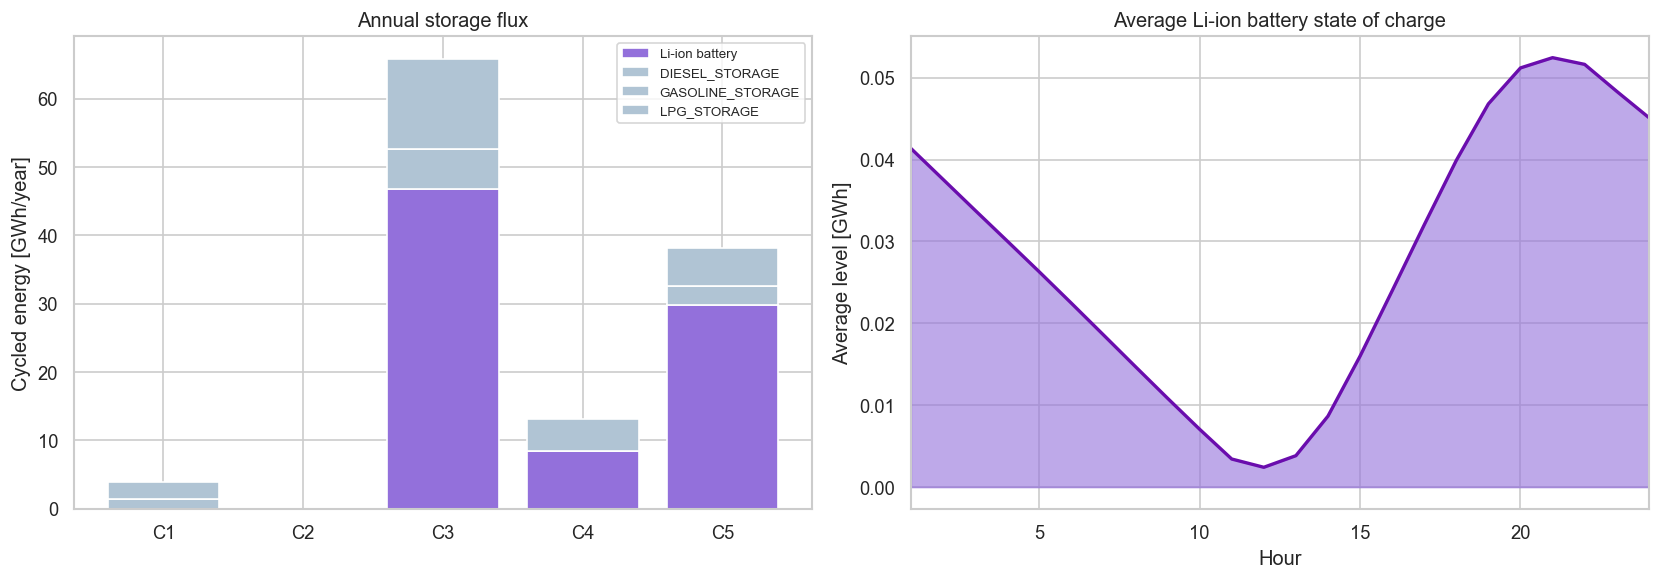

Active storage assets:
Regions     Technologies      F  Year_energy_flux  Losses
     C1   DIESEL_STORAGE  3.975             1.389     NaN
     C1 GASOLINE_STORAGE  3.798               NaN     NaN
     C1      LPG_STORAGE  1.326             2.479     NaN
     C3          BATT_LI    NaN            46.774  -5.238
     C3   DIESEL_STORAGE 19.297             5.884     NaN
     C3 GASOLINE_STORAGE 17.880               NaN     NaN
     C3      LPG_STORAGE  5.465            13.169     NaN
     C4          BATT_LI    NaN             8.436     NaN
     C4   DIESEL_STORAGE  7.567               NaN     NaN
     C4 GASOLINE_STORAGE  7.158               NaN     NaN
     C4      LPG_STORAGE  2.341             4.673     NaN
     C5          BATT_LI    NaN            29.712  -3.382
     C5   DIESEL_STORAGE  7.510             2.910     NaN
     C5 GASOLINE_STORAGE  7.260               NaN     NaN
     C5      LPG_STORAGE  1.948             5.514     NaN


In [28]:
s = sto_reg[sto_reg['Regions'].isin(REGIONS)].copy()
s_act = s[s[['F', 'Year_energy_flux']].abs().max(axis=1) > EPS]

if s_act.empty:
    print('No active storage asset.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # -- (a) energy cycled by region / technology ---------------------------
    ax = axes[0]
    piv = s_act.pivot_table(index='Regions', columns='Technologies', values='Year_energy_flux',
                            aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Cycled energy [GWh/year]'); ax.set_title('Annual storage flux'); ax.legend(fontsize=8)

    # -- (b) average state-of-charge profile (Storage_level) ---------------
    ax = axes[1]
    try:
        sl = pd.read_csv(HOURLY / 'Storage_level.csv', sep=';')
        sl['Storage_level'] = pd.to_numeric(sl['Storage_level'], errors='coerce').fillna(0)
        batt = sl[sl['Storage_tech'] == 'BATT_LI']
        if batt['Storage_level'].abs().sum() > EPS:
            batt = batt.copy(); batt['hour'] = (batt['Periods'] - 1) % 24 + 1
            prof = batt.groupby('hour')['Storage_level'].mean()
            ax.fill_between(prof.index, prof.values, color='#9370DB', alpha=.6)
            ax.plot(prof.index, prof.values, color='#6A0DAD', lw=2)
            ax.set_xlabel('Hour'); ax.set_ylabel('Average level [GWh]')
            ax.set_title('Average Li-ion battery state of charge'); ax.set_xlim(1, 24)
        else:
            ax.text(0.5, 0.5, 'Li-ion battery inactive', ha='center', va='center')
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'Storage_level.csv not found', ha='center', va='center')
    plt.tight_layout(); plt.show()

    print('Active storage assets:')
    print(s_act[['Regions', 'Technologies', 'F', 'Year_energy_flux', 'Losses']].round(3).to_string(index=False))

---
## 8. Curtailment & flexibility

Available renewable energy that is **not used**. Low curtailment indicates well-sized flexibility (storage); high curtailment signals poorly valorised solar surplus.

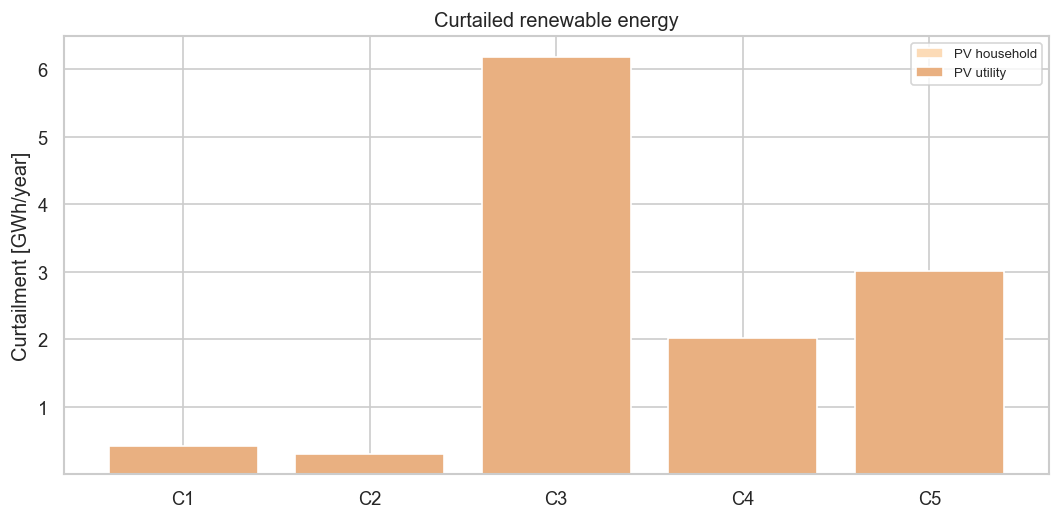

Curtailment total : 11.921 GWh/year
Taux global       : 4.73 % of renewable potential
Regions Technologies   Curt
     C1   PV_UTILITY 0.4168
     C1        PV_HS 0.0000
     C2   PV_UTILITY 0.2949
     C2        PV_HS 0.0000
     C3        PV_HS 0.0000
     C3   PV_UTILITY 6.1835
     C4        PV_HS 0.0000
     C4   PV_UTILITY 2.0113
     C5        PV_HS 0.0000
     C5   PV_UTILITY 3.0140


In [29]:
cu = curt_reg[curt_reg['Regions'].isin(REGIONS)].copy()
cu = cu[cu['Curt'] > EPS]
es = elec_supply(yb, REGIONS)

if cu.empty:
    print('OK Curtailment negligible - all renewable production is valorised.')
else:
    piv = cu.pivot_table(index='Regions', columns='Technologies', values='Curt', aggfunc='sum', fill_value=0).reindex(REGIONS).fillna(0)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(REGIONS)); bottom = np.zeros(len(REGIONS))
    for tech in piv.columns:
        ax.bar(x, piv[tech].values, bottom=bottom, label=get_label(tech), color=get_color(tech), edgecolor='white')
        bottom += piv[tech].values
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel('Curtailment [GWh/year]'); ax.set_title('Curtailed renewable energy'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    prod_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
    tot_curt = cu['Curt'].sum()
    print(f'Curtailment total : {tot_curt:.3f} GWh/year')
    print(f'Taux global       : {tot_curt/(tot_curt+prod_renew)*100:.2f} % of renewable potential')
    print(cu[['Regions', 'Technologies', 'Curt']].round(4).to_string(index=False))

---
## 9. Inter-regional exchanges

Annual flows exchanged between cells (power lines, fuel transport). Reveals regional specialisation and potential hub roles.

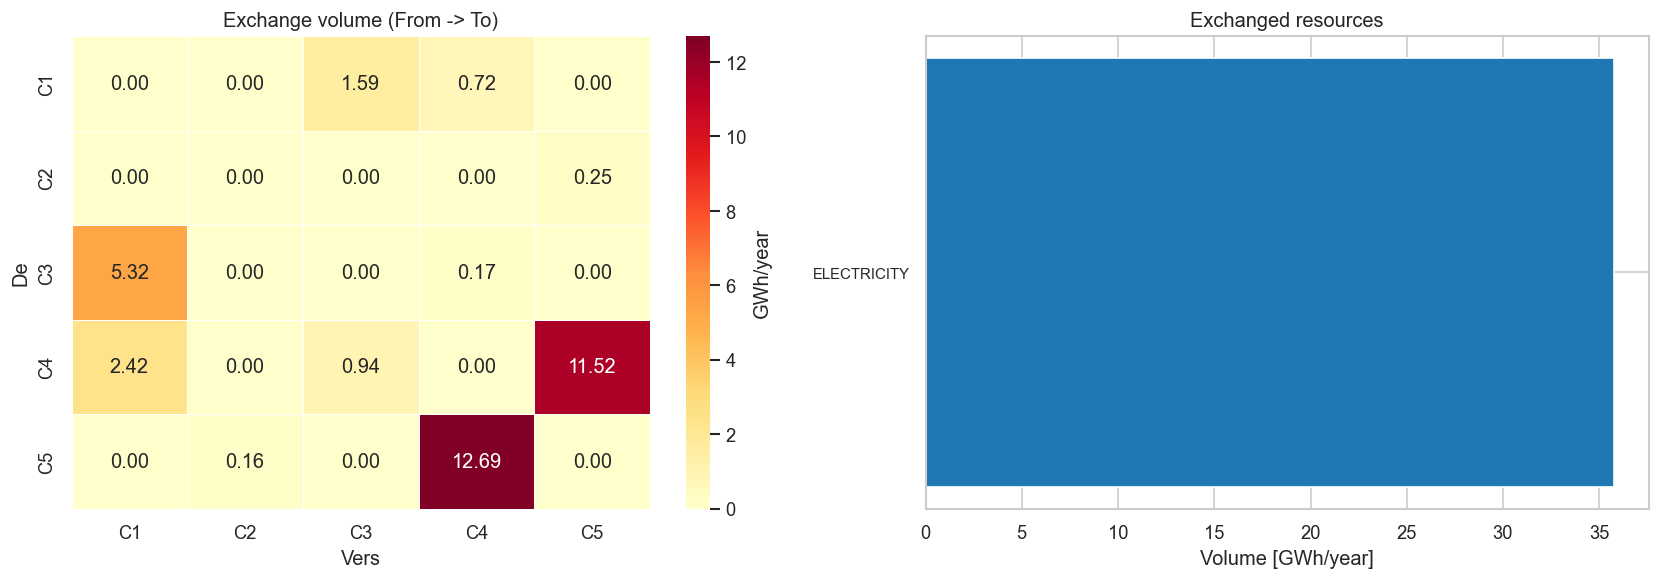

From To   Resources  Exchanges_year
  C1 C3 ELECTRICITY           1.587
  C1 C4 ELECTRICITY           0.723
  C2 C5 ELECTRICITY           0.253
  C3 C1 ELECTRICITY           5.320
  C3 C4 ELECTRICITY           0.172
  C4 C1 ELECTRICITY           2.415
  C4 C3 ELECTRICITY           0.943
  C4 C5 ELECTRICITY          11.523
  C5 C2 ELECTRICITY           0.156
  C5 C4 ELECTRICITY          12.692


In [30]:
e = exch_reg.copy()
e['Exchanges_year'] = e['Exchanges_year'].fillna(0)
cross = e[(e['From'].isin(REGIONS)) & (e['To'].isin(REGIONS)) &
          (e['From'] != e['To']) & (e['Exchanges_year'].abs() > EPS)]

if cross.empty:
    print('No significant inter-regional exchange (near-isolated cells).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    mat = cross.groupby(['From', 'To'])['Exchanges_year'].sum().unstack(fill_value=0).reindex(index=REGIONS, columns=REGIONS, fill_value=0)
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=.5, cbar_kws={'label': 'GWh/year'})
    ax.set_title('Exchange volume (From -> To)'); ax.set_xlabel('Vers'); ax.set_ylabel('De')
    ax = axes[1]
    byres = cross.groupby('Resources')['Exchanges_year'].sum().sort_values(ascending=True)
    byres = byres[byres.abs() > EPS]
    ax.barh(range(len(byres)), byres.values, color=sns.color_palette('tab10', len(byres)))
    ax.set_yticks(range(len(byres))); ax.set_yticklabels(byres.index, fontsize=9)
    ax.set_xlabel('Volume [GWh/year]'); ax.set_title('Exchanged resources')
    plt.tight_layout(); plt.show()
    print(cross[['From', 'To', 'Resources', 'Exchanges_year']].round(3).to_string(index=False))

---
## 10. Hourly profiles - electric dispatch vs demand

EnergyScope represente l'annee par **16 journees typiques**. On superpose ici la **production** (empilee par techno) et la **demande electrique** (courbe noire) pour visualiser comment l'offre suit la charge, journee typique par journee typique.

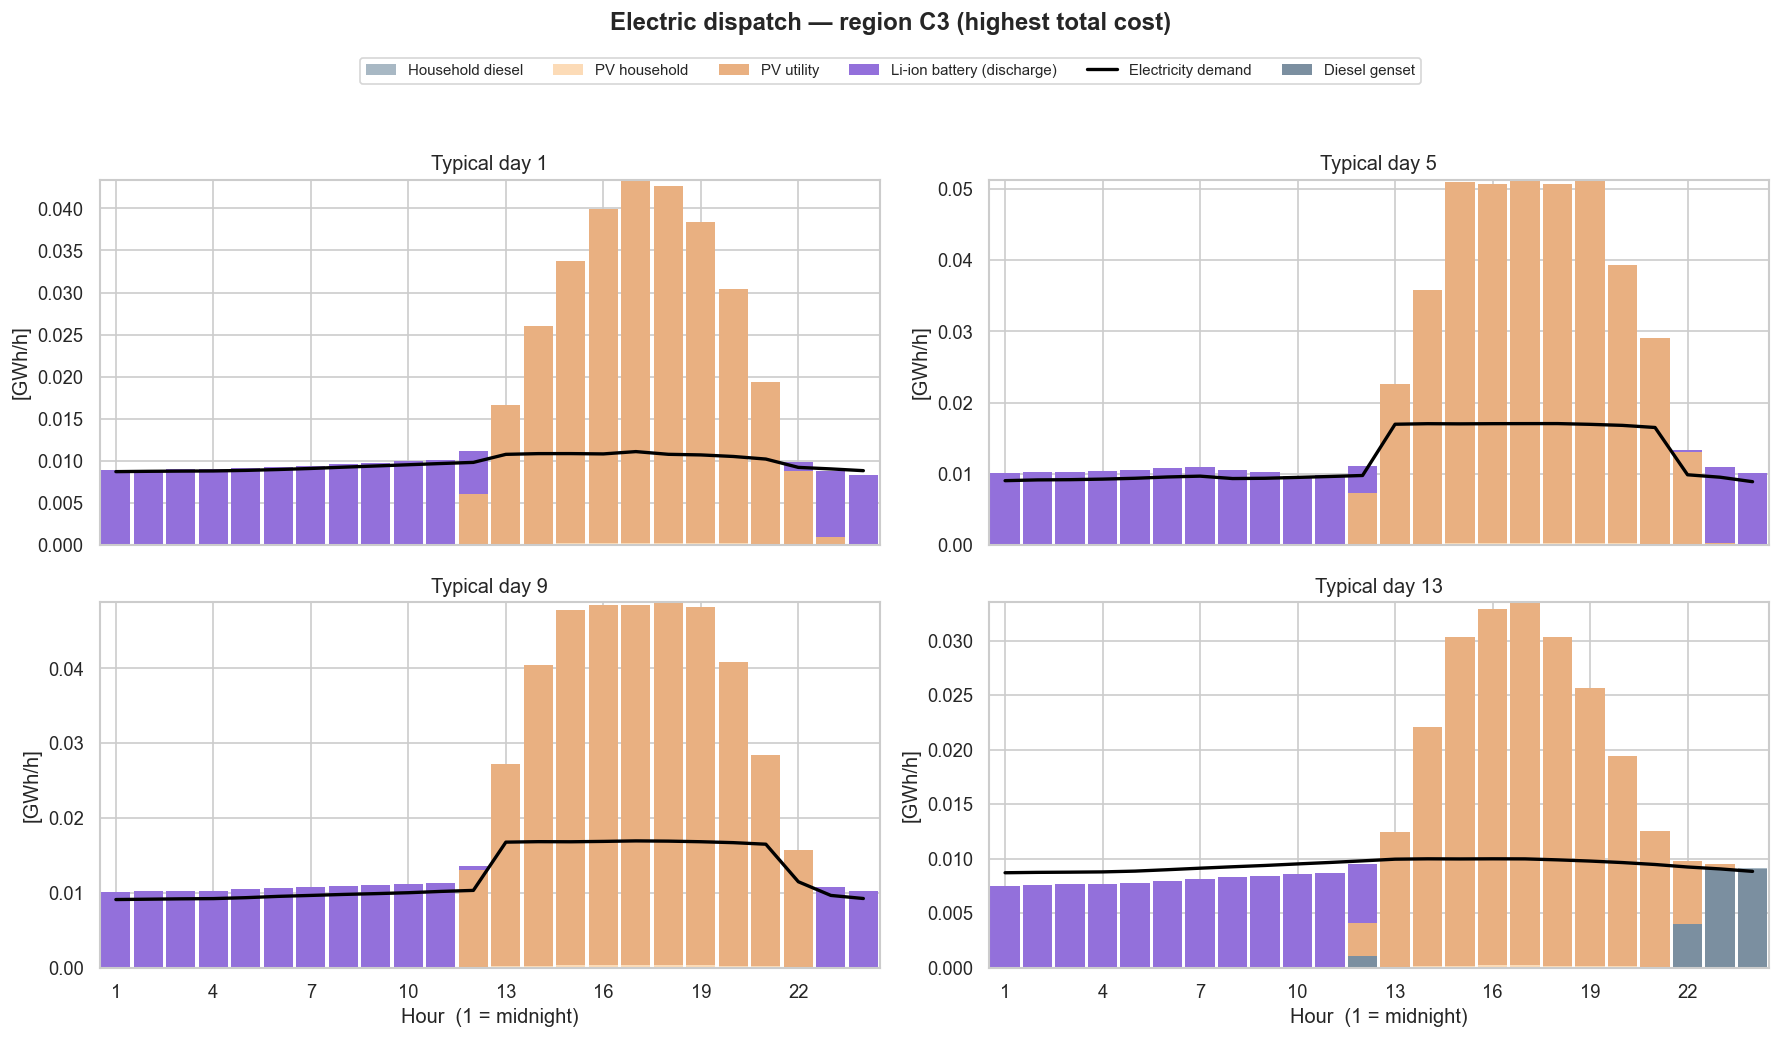

Region : C3  |  Typical days shown : [1, 5, 9, 13]
Generator techs in year balance : ['GENSET_DIESEL', 'HS_DIESEL', 'PV_HS', 'PV_UTILITY']
Active electricity consumers : ['AGR_MACHINERY_EL', 'ATM_CCS', 'BIOMASS_TO_HVC', 'BOAT_FREIGHT_ELEC', 'BUS_ELEC_PRIVATE', 'BUS_ELEC_PUBLIC', 'CARGO_FUELCELL_LH2', 'CARGO_MOTORCYCLE_ELEC', 'CAR_BEV', 'CAR_PHEV', 'COMM_MACHINERY_EL', 'CONVENTIONAL_BULB', 'CONVENTIONAL_LIGHT', 'DEC_DIRECT_ELEC', 'DEC_ELEC_COLD', 'DEC_HP_ELEC', 'DHN_HP_ELEC', 'FISH_MACHINERY_EL', 'GAS_TO_HVC', 'H2_ELECTROLYSIS', 'H2_TO_JET_FUEL', 'H2_TO_LFO', 'HABER_BOSCH', 'INDUSTRY_CCS', 'IND_DIRECT_ELEC', 'IND_ELEC_COLD', 'IND_MACHINERY_EL', 'LED_BULB', 'LED_LIGHT', 'MIN_MACHINERY_EL', 'MOTORCYCLE_ELEC_PRIVATE', 'MOTORCYCLE_ELEC_PUBLIC', 'OIL_TO_HVC', 'PICKUP_TRUCK_ELEC_PRIVATE', 'PICKUP_TRUCK_ELEC_PUBLIC', 'POWER_TO_JET_FUEL', 'POWER_TO_LFO', 'REFRIGERATOR_EL', 'STOVE_ELEC', 'SUV_ELEC_PRIVATE', 'SUV_ELEC_PUBLIC', 'SYN_METHANOLATION', 'TRACTOR_EL', 'TRAIN_FREIGHT_ELEC', 'TRAIN_PUB', 

In [31]:
# ── Load hourly data ────────────────────────────────────────────────────────
ft = pd.read_csv(HOURLY / 'F_t.csv', sep=';')
ft['F_t'] = pd.to_numeric(ft['F_t'], errors='coerce').fillna(0)

# Storage_power.csv: Storage_out >= 0 (discharge), Storage_in <= 0 (charge)
sp = pd.read_csv(HOURLY / 'Storage_power.csv', sep=';')
sp['Storage_out'] = pd.to_numeric(sp['Storage_out'], errors='coerce').fillna(0)
sp['Storage_in']  = pd.to_numeric(sp['Storage_in'],  errors='coerce').fillna(0)

# R_t_exterior.csv: hourly resource imports from outside the cell
rt_ext = pd.read_csv(HOURLY / 'R_t_exterior.csv', sep=';')
rt_ext['R_t_exterior'] = pd.to_numeric(rt_ext['R_t_exterior'], errors='coerce').fillna(0)

# Layers_in_out: electricity consumers (coef < 0) → |coef| used to weight F_t
lio = pd.read_csv(DATA_DIR / '00_INDEP' / 'Layers_in_out.csv', sep=';', index_col=0)
elec_consumer_coef = lio[lio['ELECTRICITY'] < 0]['ELECTRICITY'].abs()
active_consumers = elec_consumer_coef.index.intersection(ft['Technologies'].unique())

REGION_ANALYSE = total_cost.sort_values('TotalCost', ascending=False).iloc[0]['Regions']
HOURS = list(range(1, 25))

# Generators that produce electricity (from year balance, no imports, no storage)
gen_techs = set(elec_supply(yb, REGIONS)['Elements']) - IMPORT_ELEC

diesel_tds = sorted(
    ft[(ft['Regions'] == REGION_ANALYSE) & (ft['Technologies'] == 'GENSET_DIESEL') & (ft['F_t'] > EPS)]
    ['Typical_days'].unique().tolist()
)
TD_SHOW = [1, 5, 9, 13]
if diesel_tds and not any(td in diesel_tds for td in TD_SHOW):
    TD_SHOW[1] = diesel_tds[0]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
all_handles = {}

for ax, td in zip(axes.ravel(), TD_SHOW):
    # ── Generators ──────────────────────────────────────────────────────────
    mask_gen = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(gen_techs) & (ft['F_t'] > EPS))
    gen = (ft[mask_gen]
           .pivot_table(index='Hours', columns='Technologies', values='F_t', aggfunc='sum', fill_value=0)
           .reindex(HOURS, fill_value=0))

    # ── SIN electricity import (R_t_exterior, resource ELECTRICITY) ──────────
    elec_imp = (rt_ext[(rt_ext['Regions'] == REGION_ANALYSE) & (rt_ext['Typical_days'] == td)
                        & (rt_ext['Resources'] == 'ELECTRICITY')]
                .set_index('Hours')['R_t_exterior']
                .reindex(HOURS, fill_value=0))

    # ── Li-ion battery discharge ──────────────────────────────────────────────
    batt = (sp[(sp['Regions'] == REGION_ANALYSE) & (sp['Typical_days'] == td)
               & (sp['Storage_tech'] == 'BATT_LI')]
            .set_index('Hours'))
    batt_dis = batt['Storage_out'].reindex(HOURS, fill_value=0)

    # ── Stacked bars (generators → SIN import → battery discharge) ───────────
    bottom = np.zeros(len(HOURS))
    for tech in gen.columns:
        h = ax.bar(HOURS, gen[tech].values, bottom=bottom, color=get_color(tech), width=0.9, edgecolor='none')
        bottom += gen[tech].values
        all_handles.setdefault(get_label(tech), h[0])

    if elec_imp.sum() > EPS:
        h = ax.bar(HOURS, elec_imp.values, bottom=bottom, color=get_color('ELECTRICITY'), width=0.9, edgecolor='none')
        bottom += elec_imp.values
        all_handles.setdefault('Electricity import (SIN)', h[0])

    if batt_dis.sum() > EPS:
        h = ax.bar(HOURS, batt_dis.values, bottom=bottom, color=get_color('BATT_LI'), width=0.9, edgecolor='none')
        bottom += batt_dis.values
        all_handles.setdefault('Li-ion battery (discharge)', h[0])

    # ── Exogenous demand line (sum of consumer F_t × |Layers_in_out| coef) ───
    # Independent of supply — verifies supply ≥ demand at every hour.
    # Gap between bars and line = battery charging at that hour (excess PV stored).
    mask_dem = ((ft['Regions'] == REGION_ANALYSE) & (ft['Typical_days'] == td)
                & ft['Technologies'].isin(active_consumers))
    dem_df = ft[mask_dem].copy()
    dem_df['contrib'] = dem_df['F_t'] * dem_df['Technologies'].map(elec_consumer_coef.to_dict())
    demand = dem_df.groupby('Hours')['contrib'].sum().reindex(HOURS, fill_value=0)
    line, = ax.plot(HOURS, demand.values, color='black', lw=2)
    all_handles.setdefault('Electricity demand', line)

    ax.set_title(f'Typical day {td}')
    ax.set_xlim(0.5, 24.5)
    ax.set_xticks(range(1, 25, 3))
    ax.set_ylabel('[GWh/h]')

for ax in axes[1, :]:
    ax.set_xlabel('Hour  (1 = midnight)')

fig.legend(all_handles.values(), all_handles.keys(),
           loc='upper center', ncol=min(6, len(all_handles)), fontsize=9, bbox_to_anchor=(0.5, 1.04))
plt.suptitle(f'Electric dispatch — region {REGION_ANALYSE} (highest total cost)', y=1.08, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Region : {REGION_ANALYSE}  |  Typical days shown : {TD_SHOW}')
print(f'Generator techs in year balance : {sorted(gen_techs)}')
print(f'Active electricity consumers : {sorted(active_consumers)}')
if diesel_tds:
    print(f'GENSET_DIESEL active in TDs : {diesel_tds}')

---
## 11. Summary

Summary table for the scenario and reading guide for the thesis write-up.

In [32]:
es = elec_supply(yb, REGIONS)
dem = eud_demand(yb, REGIONS)
elec_total = es['val'].sum()
elec_renew = es[es['Elements'].isin(RENEW_ELEC)]['val'].sum()
elec_imp = es[es['Elements'].isin(IMPORT_ELEC)]['val'].sum()

line = '=' * 64
print(line); print(f'  SUMMARY - {SCENARIO}'); print(line)
print(f'  Cout total systeme         : {total_cost["TotalCost"].sum():>8.2f} M€/year')
print(f'  Demande utile servie       : {dem.values.sum():>8.1f} GWh/year')
print(f'  Cout moyen                 : {total_cost["TotalCost"].sum()*1000/dem.values.sum():>8.1f} EUR/MWh utile')
print(f'  Production electrique      : {elec_total:>8.1f} GWh/year')
print(f'     dont renouvelable local : {elec_renew/elec_total*100:>8.1f} %')
print(f'     dont importee           : {elec_imp/elec_total*100:>8.1f} %')
print(f'  Emissions CO2 (op.)        : {gwp_reg["GWP_op"].fillna(0).sum():>8.2f} kt/year')
print('-' * 64)
print('  Dominant use by region   :')
for rg in REGIONS:
    top_use = dem.loc[rg].idxmax()
    print(f'    {rg} : demand {dem.loc[rg].sum():6.1f} GWh  .  top use = {eud_label(top_use)} ({dem.loc[rg].max():.1f} GWh)')
print(line)

print('''
READING GUIDE FOR THE THESIS
  1. Demande    : quels usages dominent (cuisson ? refrigeration ?) et pourquoi
                  (climat amazonien, sufficiency vs reality) ?
  2. Supply     : why does PV dominate? what role for diesel / imports?
  3. Autonomy   : which regions depend most on external supply?
  4. Cout       : pourquoi la region la plus chere l est-elle (demande, ressource,
                  isolement) ?
  5. Robustesse : quelles technologies apparaissent dans TOUS les scenarios
                  (no-regret) vs sensibles a la demande ? -> voir la section 12,
                  qui compare sufficiency P2 a reality P1 et reality P2.''')

  SUMMARY - norte_amazonia_sufficiency_2025_phase2
  Cout total systeme         :    43.24 M€/year
  Demande utile servie       :    285.3 GWh/year
  Cout moyen                 :    151.6 EUR/MWh utile
  Production electrique      :    261.7 GWh/year
     dont renouvelable local :     91.8 %
     dont importee           :      6.5 %
  Emissions CO2 (op.)        :    48.10 kt/year
----------------------------------------------------------------
  Dominant use by region   :
    C1 : demand   34.9 GWh  .  top use = Cooking (14.4 GWh)
    C2 : demand    2.7 GWh  .  top use = Cooking (1.1 GWh)
    C3 : demand  138.3 GWh  .  top use = Cooking (53.2 GWh)
    C4 : demand   56.2 GWh  .  top use = Cooking (22.0 GWh)
    C5 : demand   53.1 GWh  .  top use = Cooking (20.3 GWh)

READING GUIDE FOR THE THESIS
  1. Demande    : quels usages dominent (cuisson ? refrigeration ?) et pourquoi
                  (climat amazonien, sufficiency vs reality) ?
  2. Supply     : why does PV dominate? what role f

---
## 12. Scenario comparison - Sufficiency P2 vs Reality

Comparaison de **`norte_amazonia_sufficiency_2025_phase2`** (reference), **`norte_amazonia_reality_2025`** (reality, phase 1) et **`norte_amazonia_reality_2025_phase2`** (reality, phase 2) sur les indicateurs cles : demande, mix electrique, couts, empreinte carbone.

Tous les ecarts sont exprimes **par rapport a Sufficiency P2**.

In [33]:
# -- Load every scenario of the comparison set -------------------------------
DS = {lab: load_scenario(ROOT / scen / 'outputs') for lab, scen in COMPARE.items()}

def kpis(D):
    yb_  = D['yb']
    tc   = D['total_cost']; tc = tc[tc['Regions'].isin(REGIONS)]
    es_  = elec_supply(yb_, REGIONS)
    dem_ = eud_demand(yb_, REGIONS)
    elec_tot   = es_['val'].sum()
    elec_renew = es_[es_['Elements'].isin(RENEW_ELEC)]['val'].sum()
    elec_imp   = es_[es_['Elements'].isin(IMPORT_ELEC)]['val'].sum()
    cost_tot   = tc['TotalCost'].sum()
    demand_tot = dem_.values.sum()
    co2_op     = pd.to_numeric(D['gwp']['GWP_op'], errors='coerce').fillna(0).sum()
    n_tech     = (D['assets'][D['assets']['F'] > EPS])['Technologies'].nunique()
    return {
        'Total cost (M€/year)':     round(cost_tot, 2),
        'Useful demand (GWh/year)': round(demand_tot, 1),
        'Average cost (€/MWh)':     round(cost_tot * 1000 / demand_tot, 1),
        'Elec. prod. (GWh/year)':   round(elec_tot, 1),
        'Renewable share (%)':      round(elec_renew / elec_tot * 100, 1),
        'Elec. import share (%)':   round(elec_imp / elec_tot * 100, 1),
        'GWP op. (kt CO2/year)':    round(co2_op, 2),
        'Deployed techs':           n_tech,
    }

comp = pd.DataFrame({lab: kpis(D) for lab, D in DS.items()})[list(COMPARE)]
for lab in COMPARE:
    if lab != SCEN_REF:
        comp[f'{lab} vs ref (%)'] = ((comp[lab] - comp[SCEN_REF]) / comp[SCEN_REF].abs() * 100).round(1)

print('=' * 96)
print(f'  COMPARISON TABLE  -  reference = {SCEN_REF}')
print('=' * 96)
print(comp.to_string())
print('=' * 96)

  COMPARISON TABLE  -  reference = Sufficiency P2
                          Sufficiency P2  Reality P1  Reality P2  Reality P1 vs ref (%)  Reality P2 vs ref (%)
Total cost (M€/year)               43.24       66.17       42.87                   53.0                   -0.9
Useful demand (GWh/year)          285.30      325.10      331.10                   14.0                   16.1
Average cost (€/MWh)              151.60      203.50      129.50                   34.2                  -14.6
Elec. prod. (GWh/year)            261.70      207.50      255.30                  -20.7                   -2.4
Renewable share (%)                91.80        4.00       82.20                  -95.6                  -10.5
Elec. import share (%)              6.50        6.60       10.70                    1.5                   64.6
GWP op. (kt CO2/year)              48.10      213.05       61.19                  342.9                   27.2
Deployed techs                     35.00       31.00       31.

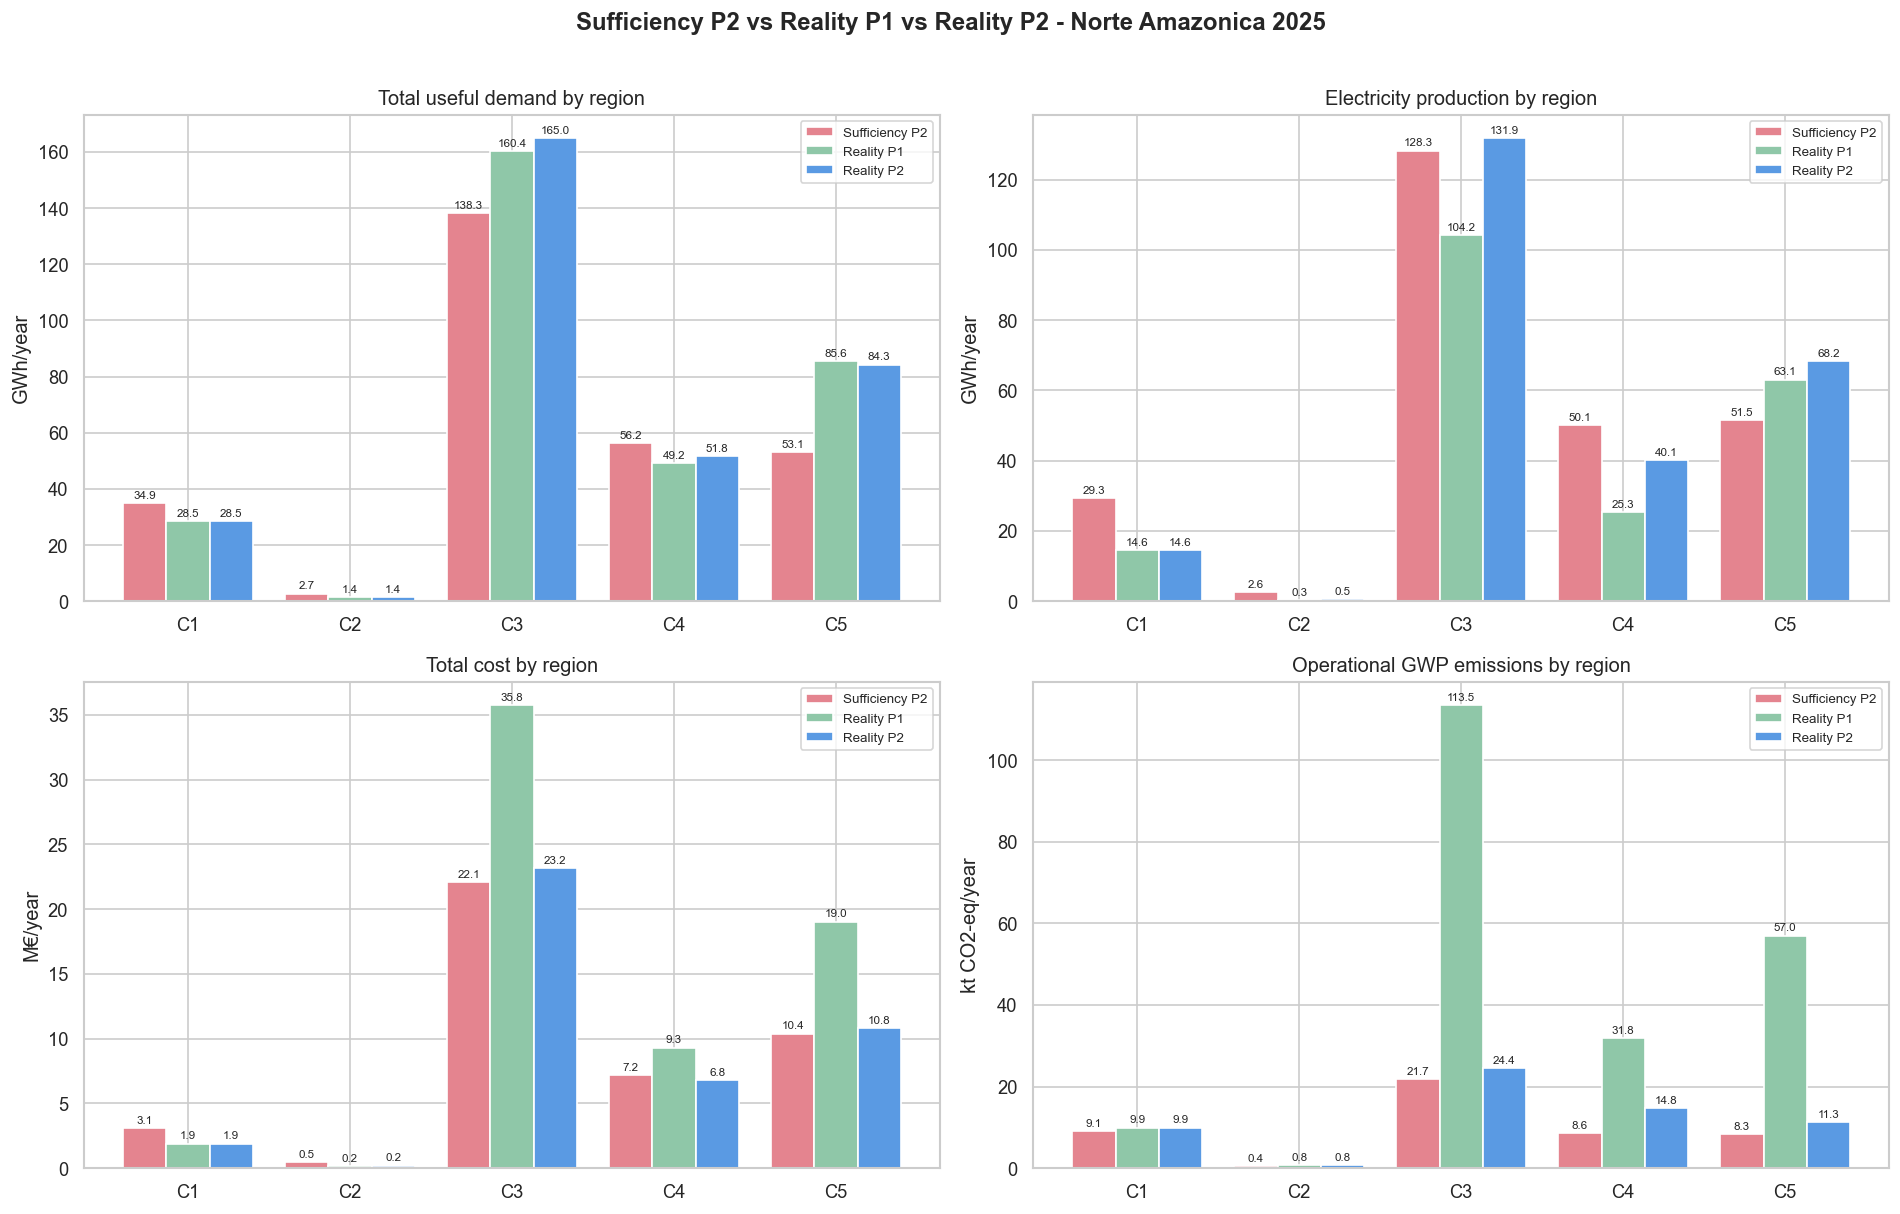

In [34]:
# -- Comparison charts by region --------------------------------------------
def by_region(D, what):
    if what == 'demand':
        return eud_demand(D['yb'], REGIONS).sum(axis=1).reindex(REGIONS).fillna(0)
    if what == 'elec':
        return elec_supply(D['yb'], REGIONS).groupby('Regions')['val'].sum().reindex(REGIONS).fillna(0)
    if what == 'cost':
        c = D['cost'][D['cost']['Regions'].isin(REGIONS)]
        return c.groupby('Regions')[['C_inv', 'C_maint', 'C_op']].sum().sum(axis=1).reindex(REGIONS).fillna(0)
    if what == 'gwp':
        g = D['gwp'][D['gwp']['Regions'].isin(REGIONS)]
        return g.groupby('Regions')['GWP_op'].sum().reindex(REGIONS).fillna(0)
    raise ValueError(what)

PANELS = [('demand', 'Total useful demand by region',        'GWh/year'),
          ('elec',   'Electricity production by region',     'GWh/year'),
          ('cost',   'Total cost by region',                 'M€/year'),
          ('gwp',    'Operational GWP emissions by region',  'kt CO2-eq/year')]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(len(REGIONS)); n = len(COMPARE); w = 0.8 / n

for ax, (what, title, unit) in zip(axes.ravel(), PANELS):
    vals = {lab: by_region(D, what) for lab, D in DS.items()}
    vmax = max(v.max() for v in vals.values()) or 1
    for k, (lab, v) in enumerate(vals.items()):
        bars = ax.bar(x + (k - (n - 1) / 2) * w, v.values, w,
                      color=SCEN_COLORS[lab], label=lab, edgecolor='white')
        for b, val in zip(bars, v.values):
            ax.text(b.get_x() + b.get_width() / 2, val + vmax * 0.01, f'{val:.1f}',
                    ha='center', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(REGIONS)
    ax.set_ylabel(unit); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle('Sufficiency P2 vs Reality P1 vs Reality P2 - Norte Amazonica 2025',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

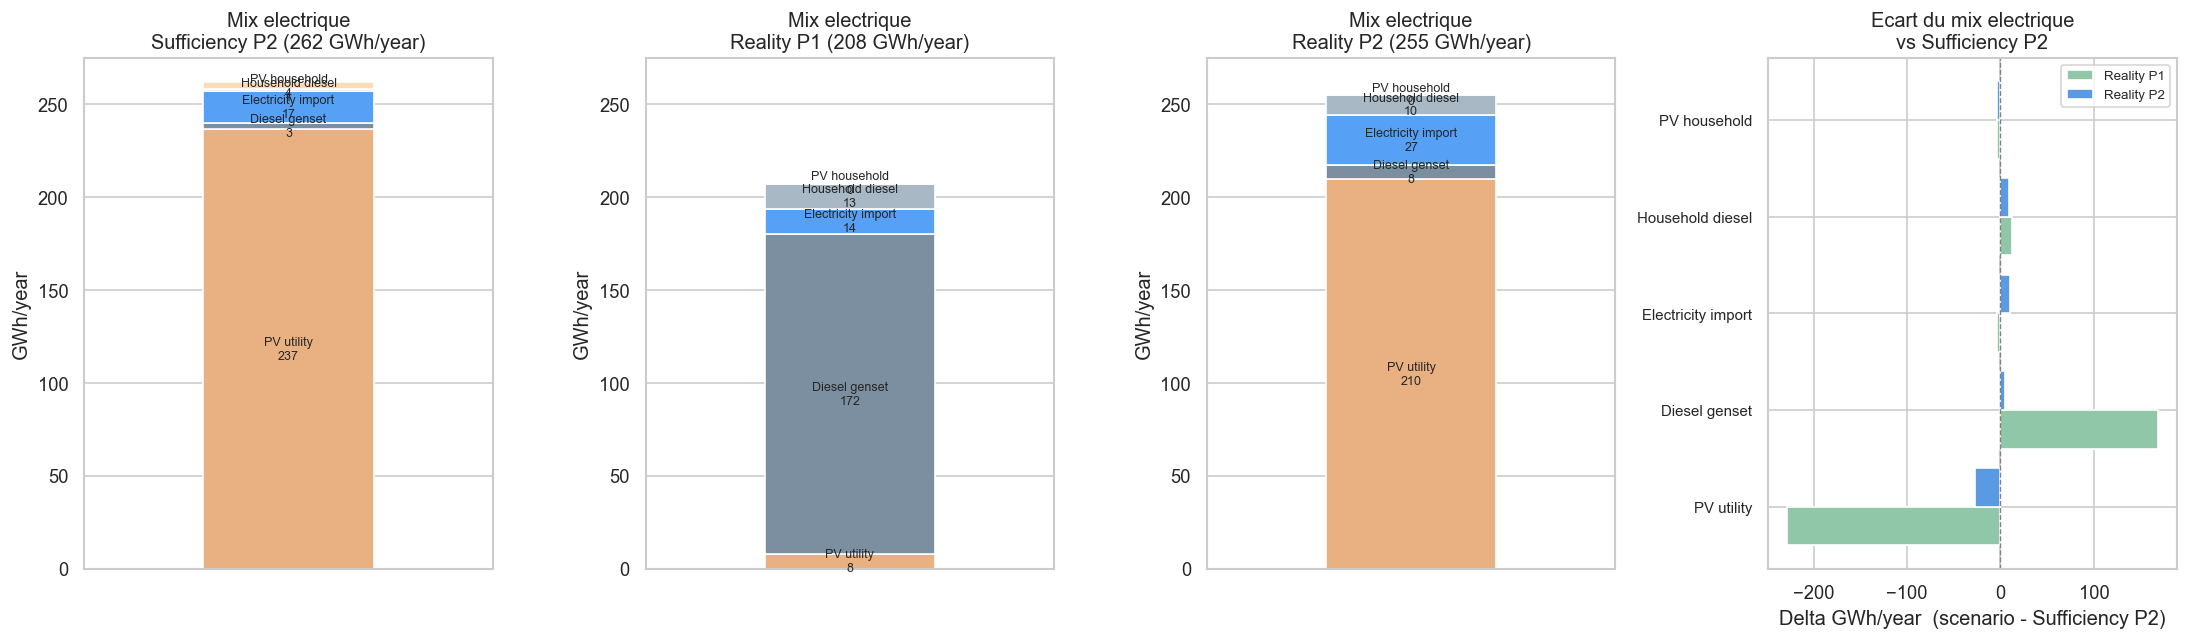

In [35]:
# -- Compared electricity mix (all regions aggregated) ----------------------
mixes = {lab: elec_supply(D['yb'], REGIONS).groupby('Elements')['val'].sum()
         for lab, D in DS.items()}
all_techs = sorted(set().union(*[set(m.index) for m in mixes.values()]),
                   key=lambda t: -sum(m.get(t, 0) for m in mixes.values()))

n = len(COMPARE)
fig, axes = plt.subplots(1, n + 1, figsize=(4.6 * (n + 1), 5.5))

for ax, (lab, mix) in zip(axes[:n], mixes.items()):
    bottom = 0
    for t in all_techs:
        v = mix.get(t, 0)
        if v > EPS:
            ax.bar(0, v, bottom=bottom, color=get_color(t), width=0.5)
            ax.text(0, bottom + v / 2, f'{get_label(t)}\n{v:.0f}',
                    ha='center', va='center', fontsize=7.5)
            bottom += v
    ax.set_xlim(-0.6, 0.6); ax.set_xticks([]); ax.set_ylabel('GWh/year')
    ax.set_title(f'Mix electrique\n{lab} ({mix.sum():.0f} GWh/year)')

ymax = max(ax.get_ylim()[1] for ax in axes[:n])     # shared scale -> panels comparable
for ax in axes[:n]:
    ax.set_ylim(0, ymax)

# -- (d) delta by technology, each scenario against the reference ------------
ax = axes[n]
others  = [lab for lab in COMPARE if lab != SCEN_REF]
techs_d = [t for t in all_techs
           if any(abs(mixes[l].get(t, 0) - mixes[SCEN_REF].get(t, 0)) > EPS for l in others)]
y = np.arange(len(techs_d)); h = 0.8 / len(others)
for k, lab in enumerate(others):
    d = [mixes[lab].get(t, 0) - mixes[SCEN_REF].get(t, 0) for t in techs_d]
    ax.barh(y + (k - (len(others) - 1) / 2) * h, d, h,
            color=SCEN_COLORS[lab], label=lab, edgecolor='white')
ax.set_yticks(y); ax.set_yticklabels([get_label(t) for t in techs_d], fontsize=9)
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Delta GWh/year  (scenario - {SCEN_REF})')
ax.set_title(f'Ecart du mix electrique\nvs {SCEN_REF}'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

CRF(10%, 30 years) = 0.10608

  GRID INFRASTRUCTURE  -  extension_capex_BC_EUR  (phase 2 only)
  CRF annualisation (10% / 30 years) - consistent with EnergyScope
Region   CAPEX total (M-euro)  Annualise CRF (M-euro/an)
--------------------------------------------------------------
C1                     21.695                      2.301
C2                      2.937                      0.312
C3                     14.943                      1.585
C4                     26.171                      2.776
C5                      0.157                      0.017
--------------------------------------------------------------
TOTAL                  65.903                      6.991


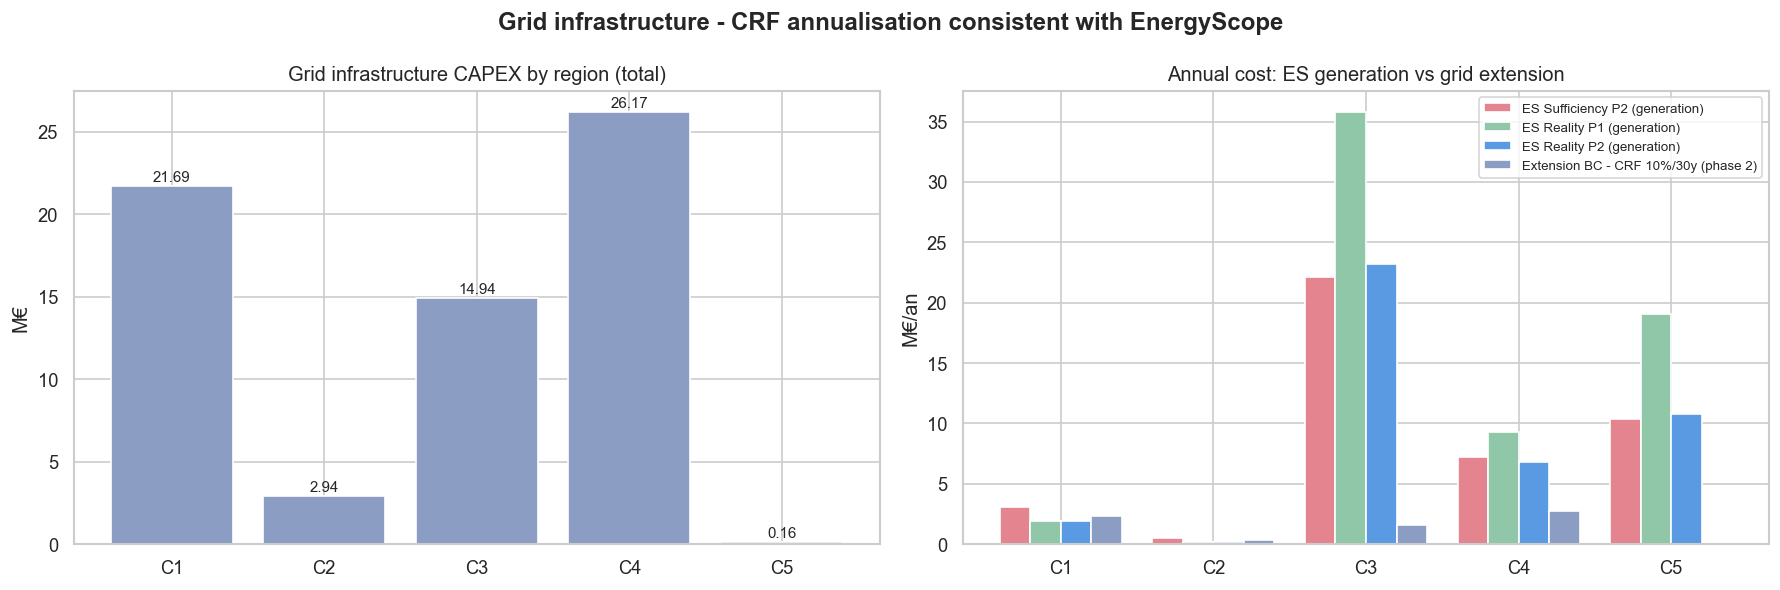


  TOTAL SYSTEM COST SUMMARY  (M-euro/year)
                                      Sufficiency P2      Reality P1      Reality P2
------------------------------------------------------------------------------------
  Generation (EnergyScope/CPLEX)              43.236          66.172          42.871
  Grid extension BC (CRF 10%/30y)              6.991           0.000           6.991
------------------------------------------------------------------------------------
  TOTAL system cost                           50.227          66.172          49.862
  Delta  Reality P1       vs Sufficiency P2 : +15.945 M-euro/year  (+31.7 %)
  Delta  Reality P2       vs Sufficiency P2 : -0.366 M-euro/year  (-0.7 %)


In [36]:
# -- Grid infrastructure (extension_capex_BC_EUR) ---------------------------
# Annualised using CRF consistent with EnergyScope (i=10%, n=30 years).
# The BC extension connects dispersed households: it is a phase-2 deployment,
# charged to the phase-2 scenarios only (PHASE2_SCEN); phase 1 -> 0.
# The per-cluster dispersion shares are geographic, so the sufficiency copy of
# the file is used for every scenario - no reality-specific version exists.
I_RATE   = 0.10
LIFETIME = 30
CRF = I_RATE * (1 + I_RATE)**LIFETIME / ((1 + I_RATE)**LIFETIME - 1)

infra = pd.read_csv(DATA / 'sufficiency' / 'share_dispersion_final_BC.csv')
infra = infra[infra['Cluster'].isin(REGIONS)].set_index('Cluster')

capex_bc   = infra['extension_capex_BC_EUR'] / 1e6   # M€ total CAPEX
annualized = capex_bc * CRF                          # M€/an (CRF)

print(f'CRF({I_RATE:.0%}, {LIFETIME} years) = {CRF:.5f}')
print()
print('=' * 62)
print('  GRID INFRASTRUCTURE  -  extension_capex_BC_EUR  (phase 2 only)')
print(f'  CRF annualisation ({I_RATE:.0%} / {LIFETIME} years) - consistent with EnergyScope')
print('=' * 62)
print(f'{"Region":<8} {"CAPEX total (M-euro)":>20} {"Annualise CRF (M-euro/an)":>26}')
print('-' * 62)
for rg in REGIONS:
    print(f'{rg:<8} {capex_bc.get(rg, 0):>20.3f} {annualized.get(rg, 0):>26.3f}')
print('-' * 62)
print(f'{"TOTAL":<8} {capex_bc.sum():>20.3f} {annualized.sum():>26.3f}')
print('=' * 62)

# -- Graphique
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(REGIONS))

ax = axes[0]
cap = capex_bc.reindex(REGIONS).fillna(0)
bars = ax.bar(x, cap.values, color='#8B9DC3', edgecolor='white')
for b, v in zip(bars, cap.values):
    ax.text(b.get_x() + b.get_width() / 2, v + cap.max() * 0.01, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€'); ax.set_title('Grid infrastructure CAPEX by region (total)')

ax = axes[1]
infra_ann = annualized.reindex(REGIONS).fillna(0)
gen_cost = {lab: by_region(D, 'cost') for lab, D in DS.items()}
n = len(gen_cost) + 1; w = 0.8 / n
for k, (lab, v) in enumerate(gen_cost.items()):
    ax.bar(x + (k - (n - 1) / 2) * w, v.values, w, color=SCEN_COLORS[lab],
           label=f'ES {lab} (generation)', edgecolor='white')
ax.bar(x + (len(gen_cost) - (n - 1) / 2) * w, infra_ann.values, w, color='#8B9DC3',
       label=f'Extension BC - CRF {I_RATE:.0%}/{LIFETIME}y (phase 2)', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(REGIONS)
ax.set_ylabel('M€/an'); ax.set_title('Annual cost: ES generation vs grid extension')
ax.legend(fontsize=8)

plt.suptitle('Grid infrastructure - CRF annualisation consistent with EnergyScope', fontweight='bold')
plt.tight_layout(); plt.show()

# -- Corrected summary table (generation + extension) ------------------------
tot_infra_ann = annualized.sum()
rows = {}
for lab, D in DS.items():
    tc = D['total_cost']
    es_cost = tc[tc['Regions'].isin(REGIONS)]['TotalCost'].sum()
    ext     = tot_infra_ann if lab in PHASE2_SCEN else 0.0
    rows[lab] = (es_cost, ext, es_cost + ext)

line = '=' * 84
print(); print(line)
print('  TOTAL SYSTEM COST SUMMARY  (M-euro/year)')
print(line)
print(f'  {"":34s}' + ''.join(f'{lab:>16}' for lab in rows))
print('-' * 84)
print(f'  {"Generation (EnergyScope/CPLEX)":34s}' + ''.join(f'{v[0]:>16.3f}' for v in rows.values()))
print(f'  {"Grid extension BC (CRF 10%/30y)":34s}' + ''.join(f'{v[1]:>16.3f}' for v in rows.values()))
print('-' * 84)
print(f'  {"TOTAL system cost":34s}' + ''.join(f'{v[2]:>16.3f}' for v in rows.values()))
print(line)
ref_tot = rows[SCEN_REF][2]
for lab, v in rows.items():
    if lab == SCEN_REF:
        continue
    d = v[2] - ref_tot
    print(f'  Delta  {lab:<16} vs {SCEN_REF} : {d:+.3f} M-euro/year  ({d / ref_tot * 100:+.1f} %)')
print(line)